# ROPAgen Document Evaluation
## ModernBERT-based NLP Metrics for 2,000-Token German GDPR Documents

**Metrics:** BLEU · ROUGE-1/2/L · METEOR · BERTScore Recall · SBERT Cosine Similarity  
**Model:** `answerdotai/ModernBERT-base` — Alternating Global-Local Attention + RoPE, 8,192-token native window  
**Hardware target:** RTX 4070 (CUDA) with batch processing to prevent OOM

In [110]:
import os, warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
load_dotenv()   # loads HF_TOKEN (and any other vars) from .env

import pandas as pd
import numpy as np
import torch
import evaluate
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm

# ── Configuration ──────────────────────────────────────────────────────────────
MODEL_NAME       = "answerdotai/ModernBERT-base"
DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"
BERT_BATCH_SIZE  = 4   # conservative for RTX 4070 + 2k-token docs
SBERT_BATCH_SIZE = 4

print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU    : {props.name}")
    print(f"VRAM   : {props.total_memory / 1e9:.1f} GB")
print(f"HF_TOKEN set: {bool(os.environ.get('HF_TOKEN'))}")

Device : cuda
GPU    : NVIDIA GeForce RTX 4070
VRAM   : 12.9 GB
HF_TOKEN set: True


In [111]:
# ── Load reference document ────────────────────────────────────────────────────
with open("docs/reference.txt", "r", encoding="utf-8") as fh:
    reference_text = fh.read().strip()

print(f"Reference length : {len(reference_text):,} chars  |  "
      f"~{len(reference_text.split()):,} words")

# ── Load candidate documents ───────────────────────────────────────────────────
df_all = pd.read_csv("docs/documents.csv")
df_all = df_all.dropna(subset=["ai_mode"])   # drop rows with missing ai_mode
print(f"\nTotal candidates : {len(df_all)}")
print(f"Columns          : {df_all.columns.tolist()}")
print(f"\nMode distribution:")
print(df_all["ai_mode"].value_counts().to_string())

# ── Split by mode ──────────────────────────────────────────────────────────────
MODES = sorted(df_all["ai_mode"].unique().tolist())
dfs_by_mode = {
    mode: df_all[df_all["ai_mode"] == mode].reset_index(drop=True)
    for mode in MODES
}
print(f"\nMode keys: {MODES}")

Reference length : 3,532 chars  |  ~393 words

Total candidates : 115
Columns          : ['id', 'user_id', 'ai_mode', 'document']

Mode distribution:
ai_mode
chat    39
form    38
ask     38

Mode keys: ['ask', 'chat', 'form']


## Metric Definitions

| Metric | Purpose | Notes |
|---|---|---|
| **BLEU** | N-gram precision overlap | Modified precision; baseline surface similarity |
| **ROUGE-1/2** | Unigram / bigram recall | Measures lexical coverage |
| **ROUGE-L** | Longest common subsequence | Captures sentence-level structure |
| **METEOR** | Synonym-aware recall | Stems + synonyms → better semantic recall than BLEU |
| **BERTScore Recall** | Token-level contextual overlap | ModernBERT embeddings; focus on *recall* per supervisor |
| **SBERT Similarity** | Global document-level cosine sim | Pooled ModernBERT embeddings; holistic semantic match |

In [112]:
# ── Load evaluate metrics (done once; reused across modes) ─────────────────────
print("Loading evaluate metrics …")
bleu_metric    = evaluate.load("bleu")
rouge_metric   = evaluate.load("rouge")
meteor_metric  = evaluate.load("meteor")
print("Done.")

# ── Baseline: BLEU · ROUGE · METEOR ───────────────────────────────────────────
def compute_baseline_metrics(candidates: list[str], reference: str) -> pd.DataFrame:
    """
    Compute BLEU, ROUGE-1, ROUGE-2, ROUGE-L, and METEOR document-by-document.

    METEOR is highlighted because it matches stems and WordNet synonyms,
    giving more credit for paraphrased recall than BLEU's precision-only view.
    """
    rows = []
    for cand in tqdm(candidates, desc="  baseline", leave=False):
        row = {}

        # BLEU — modified n-gram precision (references wrapped in a list)
        try:
            b = bleu_metric.compute(predictions=[cand], references=[[reference]])
            row["BLEU"] = b["bleu"]
        except Exception:
            row["BLEU"] = np.nan

        # ROUGE
        r = rouge_metric.compute(predictions=[cand], references=[reference])
        row["ROUGE-1"] = r["rouge1"]
        row["ROUGE-2"] = r["rouge2"]
        row["ROUGE-L"] = r["rougeL"]

        # METEOR — synonym-aware recall via stemming + WordNet alignment
        m = meteor_metric.compute(predictions=[cand], references=[reference])
        row["METEOR"] = m["meteor"]

        rows.append(row)

    return pd.DataFrame(rows)

Loading evaluate metrics …
Done.


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\emilija\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\emilija\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\emilija\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [113]:
import torch.nn.functional as F

# ── Load ModernBERT once for BERTScore (evaluate's bert_score library does not
#    support ModernBERT's architecture — we call AutoModel directly instead) ────
print(f"Loading tokenizer & model for BERTScore: {MODEL_NAME} …")
_bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
_bert_model     = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
_bert_model.eval()
print("Done.")


def _embed_texts(texts: list[str], batch_size: int) -> list[torch.Tensor]:
    """Return one L2-normalised (valid_tokens × hidden_dim) tensor per text."""
    embeddings: list[torch.Tensor] = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        enc = _bert_tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=8192,
            return_tensors="pt",
        ).to(DEVICE)
        with torch.no_grad():
            out = _bert_model(**enc)
        hidden = out.last_hidden_state        # (B, T, H)
        mask   = enc["attention_mask"].bool() # (B, T)
        for j in range(len(batch)):
            emb = hidden[j][mask[j]]          # strip padding → (T_valid, H)
            embeddings.append(F.normalize(emb, dim=-1))
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
    return embeddings


def compute_bertscore(
    candidates: list[str],
    reference: str,
    batch_size: int = BERT_BATCH_SIZE,
) -> tuple[list[float], list[float], list[float]]:
    """
    BERTScore Precision, Recall, and F1 using ModernBERT token embeddings.

    P_BERT  = mean over candidate tokens of max cosine sim to any reference token
    R_BERT  = mean over reference tokens  of max cosine sim to any candidate token
    F1_BERT = harmonic mean of P and R

    Because embeddings are L2-normalised, cosine sim = dot product.
    """
    [ref_emb] = _embed_texts([reference], batch_size=1)   # (T_ref, H)
    cand_embs  = _embed_texts(candidates, batch_size=batch_size)

    precisions, recalls, f1s = [], [], []
    for c_emb in tqdm(cand_embs, desc="  BERTScore", leave=False):
        sim = ref_emb @ c_emb.T                          # (T_ref, T_cand)
        r   = sim.max(dim=1).values.mean().item()        # recall:    max over cand per ref token
        p   = sim.max(dim=0).values.mean().item()        # precision: max over ref  per cand token
        f1  = (2 * p * r / (p + r)) if (p + r) > 0 else 0.0
        precisions.append(p)
        recalls.append(r)
        f1s.append(f1)

    return precisions, recalls, f1s

Loading tokenizer & model for BERTScore: answerdotai/ModernBERT-base …


Loading weights: 100%|██████████| 134/134 [00:00<00:00, 15576.22it/s]
ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Done.


In [114]:
# ── SBERT Global Semantic Similarity (ModernBERT-base, CUDA, batched) ──────────
print(f"Loading SentenceTransformer: {MODEL_NAME} …")
sbert_model = SentenceTransformer(MODEL_NAME, device=DEVICE)

# Override the default 512-token limit; ModernBERT supports 8,192 natively
sbert_model.max_seq_length = 8192
print(f"Max seq length : {sbert_model.max_seq_length}")
print(f"Embedding dim  : {sbert_model.get_sentence_embedding_dimension()}")

# Pre-encode the reference once (reused for every mode)
ref_embedding = sbert_model.encode(
    [reference_text],
    batch_size=1,
    convert_to_numpy=True,
    normalize_embeddings=True,   # L2-normalise → dot product == cosine sim
    show_progress_bar=False,
)   # shape: (1, hidden_dim)

def compute_sbert_similarity(
    candidates: list[str],
    batch_size: int = SBERT_BATCH_SIZE,
) -> list[float]:
    """
    Encode each candidate with the shared ModernBERT SentenceTransformer and
    compute cosine similarity against the pre-encoded reference embedding.

    Because both vectors are L2-normalised, cosine similarity reduces to a
    simple dot product — no extra trig needed.
    """
    cand_embeddings = sbert_model.encode(
        candidates,
        batch_size=batch_size,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )   # shape: (n, hidden_dim)

    # dot product of unit vectors == cosine similarity
    sims = (cand_embeddings @ ref_embedding.T).squeeze()

    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    # ensure we always return a plain Python list
    return sims.tolist() if hasattr(sims, "tolist") else [float(sims)]

Loading SentenceTransformer: answerdotai/ModernBERT-base …


Loading weights: 100%|██████████| 134/134 [00:00<00:00, 13505.30it/s]
ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Max seq length : 8192
Embedding dim  : 768


In [115]:
# ── Compute all metrics per mode ───────────────────────────────────────────────
METRIC_COLS = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR",
               "BERTScore_Precision", "BERTScore_Recall", "BERTScore_F1",
               "SBERT_Similarity"]

mode_results: dict[str, pd.DataFrame] = {}

for mode in MODES:
    df_mode    = dfs_by_mode[mode]
    candidates = df_mode["document"].astype(str).tolist()
    n          = len(candidates)

    print(f"\n{'═'*60}")
    print(f"  Mode: '{mode}'  ({n} documents)")
    print(f"{'═'*60}")

    # 1. Lexical / surface metrics
    df_base = compute_baseline_metrics(candidates, reference_text)

    # 2. BERTScore Precision, Recall, F1 — ModernBERT token-level
    precisions, recalls, f1s = compute_bertscore(candidates, reference_text)

    # 3. SBERT Cosine Similarity — global document-level semantic similarity
    sims = compute_sbert_similarity(candidates)

    # Assemble per-mode DataFrame
    df_result = df_mode[["id", "user_id", "ai_mode"]].copy()
    df_result = pd.concat(
        [df_result.reset_index(drop=True),
         df_base.reset_index(drop=True),
         pd.Series(precisions, name="BERTScore_Precision"),
         pd.Series(recalls,    name="BERTScore_Recall"),
         pd.Series(f1s,        name="BERTScore_F1"),
         pd.Series(sims,       name="SBERT_Similarity")],
        axis=1,
    )

    mode_results[mode] = df_result

    print(f"\n  Summary statistics for mode '{mode}':")
    display(df_result[METRIC_COLS].describe().round(4))


════════════════════════════════════════════════════════════
  Mode: 'ask'  (38 documents)
════════════════════════════════════════════════════════════



  Summary statistics for mode 'ask':


,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,METEOR,BERTScore_Precision,BERTScore_Recall,BERTScore_F1,SBERT_Similarity
count,38.0000,38.0000,38.0000,38.0000,38.0000,38.0000,38.0000,38.0000,38.0000
mean,0.1267,0.4675,0.2577,0.3484,0.3654,0.8860,0.9082,0.8968,0.9860
std,0.0552,0.0874,0.0786,0.0903,0.0672,0.0159,0.0169,0.0129,0.0047
min,0.0469,0.3219,0.1206,0.1944,0.2336,0.8609,0.8614,0.8629,0.9705
25%,0.0834,0.4133,0.2003,0.2967,0.3297,0.8728,0.9075,0.8923,0.9831
50%,0.1224,0.4492,0.2386,0.3276,0.3668,0.8853,0.9142,0.8954,0.9869
75%,0.1474,0.5239,0.2864,0.3851,0.4062,0.8988,0.9181,0.9051,0.9896
max,0.2463,0.6176,0.4287,0.5452,0.4880,0.9179,0.9253,0.9180,0.9926



════════════════════════════════════════════════════════════
  Mode: 'chat'  (39 documents)
════════════════════════════════════════════════════════════



  Summary statistics for mode 'chat':


,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,METEOR,BERTScore_Precision,BERTScore_Recall,BERTScore_F1,SBERT_Similarity
count,39.0000,39.0000,39.0000,39.0000,39.0000,39.0000,39.0000,39.0000,39.0000
mean,0.1430,0.5106,0.2913,0.3892,0.3902,0.8954,0.9130,0.9041,0.9895
std,0.0390,0.0705,0.0685,0.0721,0.0571,0.0117,0.0132,0.0101,0.0022
min,0.0668,0.3303,0.1310,0.2304,0.2352,0.8670,0.8737,0.8719,0.9850
25%,0.1216,0.4682,0.2526,0.3479,0.3741,0.8900,0.9076,0.8992,0.9880
50%,0.1341,0.5173,0.2832,0.3868,0.3885,0.8958,0.9167,0.9064,0.9901
75%,0.1631,0.5608,0.3443,0.4443,0.4211,0.9019,0.9218,0.9105,0.9912
max,0.2351,0.6446,0.4471,0.5443,0.5012,0.9219,0.9329,0.9219,0.9936



════════════════════════════════════════════════════════════
  Mode: 'form'  (38 documents)
════════════════════════════════════════════════════════════



  Summary statistics for mode 'form':


,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,METEOR,BERTScore_Precision,BERTScore_Recall,BERTScore_F1,SBERT_Similarity
count,38.0000,38.0000,38.0000,38.0000,38.0000,38.0000,38.0000,38.0000,38.0000
mean,0.1252,0.4775,0.2997,0.3802,0.4031,0.8880,0.9187,0.9029,0.9846
std,0.0513,0.1153,0.0845,0.1043,0.0760,0.0141,0.0242,0.0166,0.0115
min,0.0002,0.1027,0.0673,0.0893,0.0588,0.8622,0.7768,0.8186,0.9195
25%,0.0875,0.4090,0.2409,0.3133,0.3662,0.8801,0.9186,0.8990,0.9839
50%,0.1148,0.4890,0.2950,0.3861,0.4152,0.8882,0.9218,0.9054,0.9874
75%,0.1580,0.5674,0.3608,0.4640,0.4409,0.8986,0.9253,0.9117,0.9892
max,0.2297,0.6441,0.4549,0.5656,0.5142,0.9124,0.9355,0.9201,0.9921


In [116]:
# ── Combine all modes into one master DataFrame ────────────────────────────────
df_combined = pd.concat(mode_results.values(), ignore_index=True)

print("=" * 65)
print(f"  COMBINED RESULTS  —  {len(df_combined)} document pairs  ×  {len(METRIC_COLS)} metrics")
print("=" * 65)

print("\nSample rows (first 5):")
display(df_combined[["ai_mode"] + METRIC_COLS].head())


# ── Helper: describe() + median label + highest/lowest document ID ─────────────
def build_summary(df: pd.DataFrame) -> pd.DataFrame:
    stats = df[METRIC_COLS].describe().round(4)
    stats = stats.rename(index={"50%": "median"})
    stats.loc["highest_id"] = {col: df.loc[df[col].idxmax(), "id"] for col in METRIC_COLS}
    stats.loc["lowest_id"]  = {col: df.loc[df[col].idxmin(), "id"] for col in METRIC_COLS}
    return stats


# ── Overall (all modes combined) ───────────────────────────────────────────────
print("\n── Overall (all modes) ──")
df_summary_overall = build_summary(df_combined)
display(df_summary_overall)

# ── Per-mode detailed tables ───────────────────────────────────────────────────
df_summaries = {}
for mode in MODES:
    print(f"\n── Mode: {mode} ──")
    df_summaries[mode] = build_summary(mode_results[mode])
    display(df_summaries[mode])

# ── Side-by-side mean comparison (all modes) ──────────────────────────────────
print("\n── Per-mode mean scores (comparison) ──")
display(df_combined.groupby("ai_mode")[METRIC_COLS].mean().round(4))

# ── Save ───────────────────────────────────────────────────────────────────────
OUT = "output"

df_combined.to_csv(f"{OUT}/document_results.csv", index=False)

print("\nSaved:")
print(f"  {OUT}/document_results.csv   — full per-document scores")


  COMBINED RESULTS  —  115 document pairs  ×  9 metrics

Sample rows (first 5):


,ai_mode,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,METEOR,BERTScore_Precision,BERTScore_Recall,BERTScore_F1,SBERT_Similarity
0,ask,0.093839,0.420000,0.253672,0.329333,0.408575,0.874936,0.921125,0.897437,0.980798
1,ask,0.085126,0.449723,0.236320,0.318290,0.378338,0.889974,0.918140,0.903838,0.987080
2,ask,0.112402,0.449731,0.252114,0.331543,0.399164,0.878522,0.918389,0.898013,0.984948
3,ask,0.074148,0.420077,0.202630,0.287259,0.349963,0.873989,0.918056,0.895481,0.985839
4,ask,0.220772,0.599303,0.365541,0.487805,0.472723,0.911353,0.919198,0.915259,0.991606



── Overall (all modes) ──


,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,METEOR,BERTScore_Precision,BERTScore_Recall,BERTScore_F1,SBERT_Similarity
count,115.0000,115.0000,115.0000,115.0000,115.0000,115.0000,115.0000,115.0000,115.0000
mean,0.1317,0.4854,0.2830,0.3727,0.3863,0.8899,0.9133,0.9013,0.9867
std,0.0492,0.0938,0.0788,0.0907,0.0683,0.0145,0.0189,0.0137,0.0075
min,0.0002,0.1027,0.0673,0.0893,0.0588,0.8609,0.7768,0.8186,0.9195
25%,0.0938,0.4233,0.2335,0.3111,0.3586,0.8793,0.9134,0.8941,0.9850
median,0.1276,0.4906,0.2683,0.3593,0.3864,0.8907,0.9181,0.9038,0.9882
75%,0.1588,0.5601,0.3411,0.4390,0.4301,0.8997,0.9221,0.9095,0.9902
max,0.2463,0.6446,0.4549,0.5656,0.5142,0.9219,0.9355,0.9219,0.9936
highest_id,29.0000,4.0000,67.0000,67.0000,3.0000,36.0000,44.0000,4.0000,37.0000
lowest_id,115.0000,115.0000,115.0000,115.0000,115.0000,32.0000,115.0000,115.0000,115.0000



── Mode: ask ──


...


── Mode: form ──


,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,METEOR,BERTScore_Precision,BERTScore_Recall,BERTScore_F1,SBERT_Similarity
count,38.0000,38.0000,38.0000,38.0000,38.0000,38.0000,38.0000,38.0000,38.0000
mean,0.1252,0.4775,0.2997,0.3802,0.4031,0.8880,0.9187,0.9029,0.9846
std,0.0513,0.1153,0.0845,0.1043,0.0760,0.0141,0.0242,0.0166,0.0115
min,0.0002,0.1027,0.0673,0.0893,0.0588,0.8622,0.7768,0.8186,0.9195
25%,0.0875,0.4090,0.2409,0.3133,0.3662,0.8801,0.9186,0.8990,0.9839
median,0.1148,0.4890,0.2950,0.3861,0.4152,0.8882,0.9218,0.9054,0.9874
75%,0.1580,0.5674,0.3608,0.4640,0.4409,0.8986,0.9253,0.9117,0.9892
max,0.2297,0.6441,0.4549,0.5656,0.5142,0.9124,0.9355,0.9201,0.9921
highest_id,67.0000,24.0000,67.0000,67.0000,3.0000,41.0000,44.0000,104.0000,21.0000
lowest_id,115.0000,115.0000,115.0000,115.0000,115.0000,110.0000,115.0000,115.0000,115.0000



── Per-mode mean scores (comparison) ──


,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,METEOR,BERTScore_Precision,BERTScore_Recall,BERTScore_F1,SBERT_Similarity
ai_mode,,,,,,,,,
ask,0.1267,0.4675,0.2577,0.3484,0.3654,0.8860,0.9082,0.8968,0.9860
chat,0.1430,0.5106,0.2913,0.3892,0.3902,0.8954,0.9130,0.9041,0.9895
form,0.1252,0.4775,0.2997,0.3802,0.4031,0.8880,0.9187,0.9029,0.9846



Saved:
  output/document_results.csv   — full per-document scores


## Visualisation — Per-Metric Boxplots

One boxplot per metric (BLEU · ROUGE-1/2/L · METEOR · BERTScore Recall · SBERT Similarity), comparing distributions across AI generation modes.

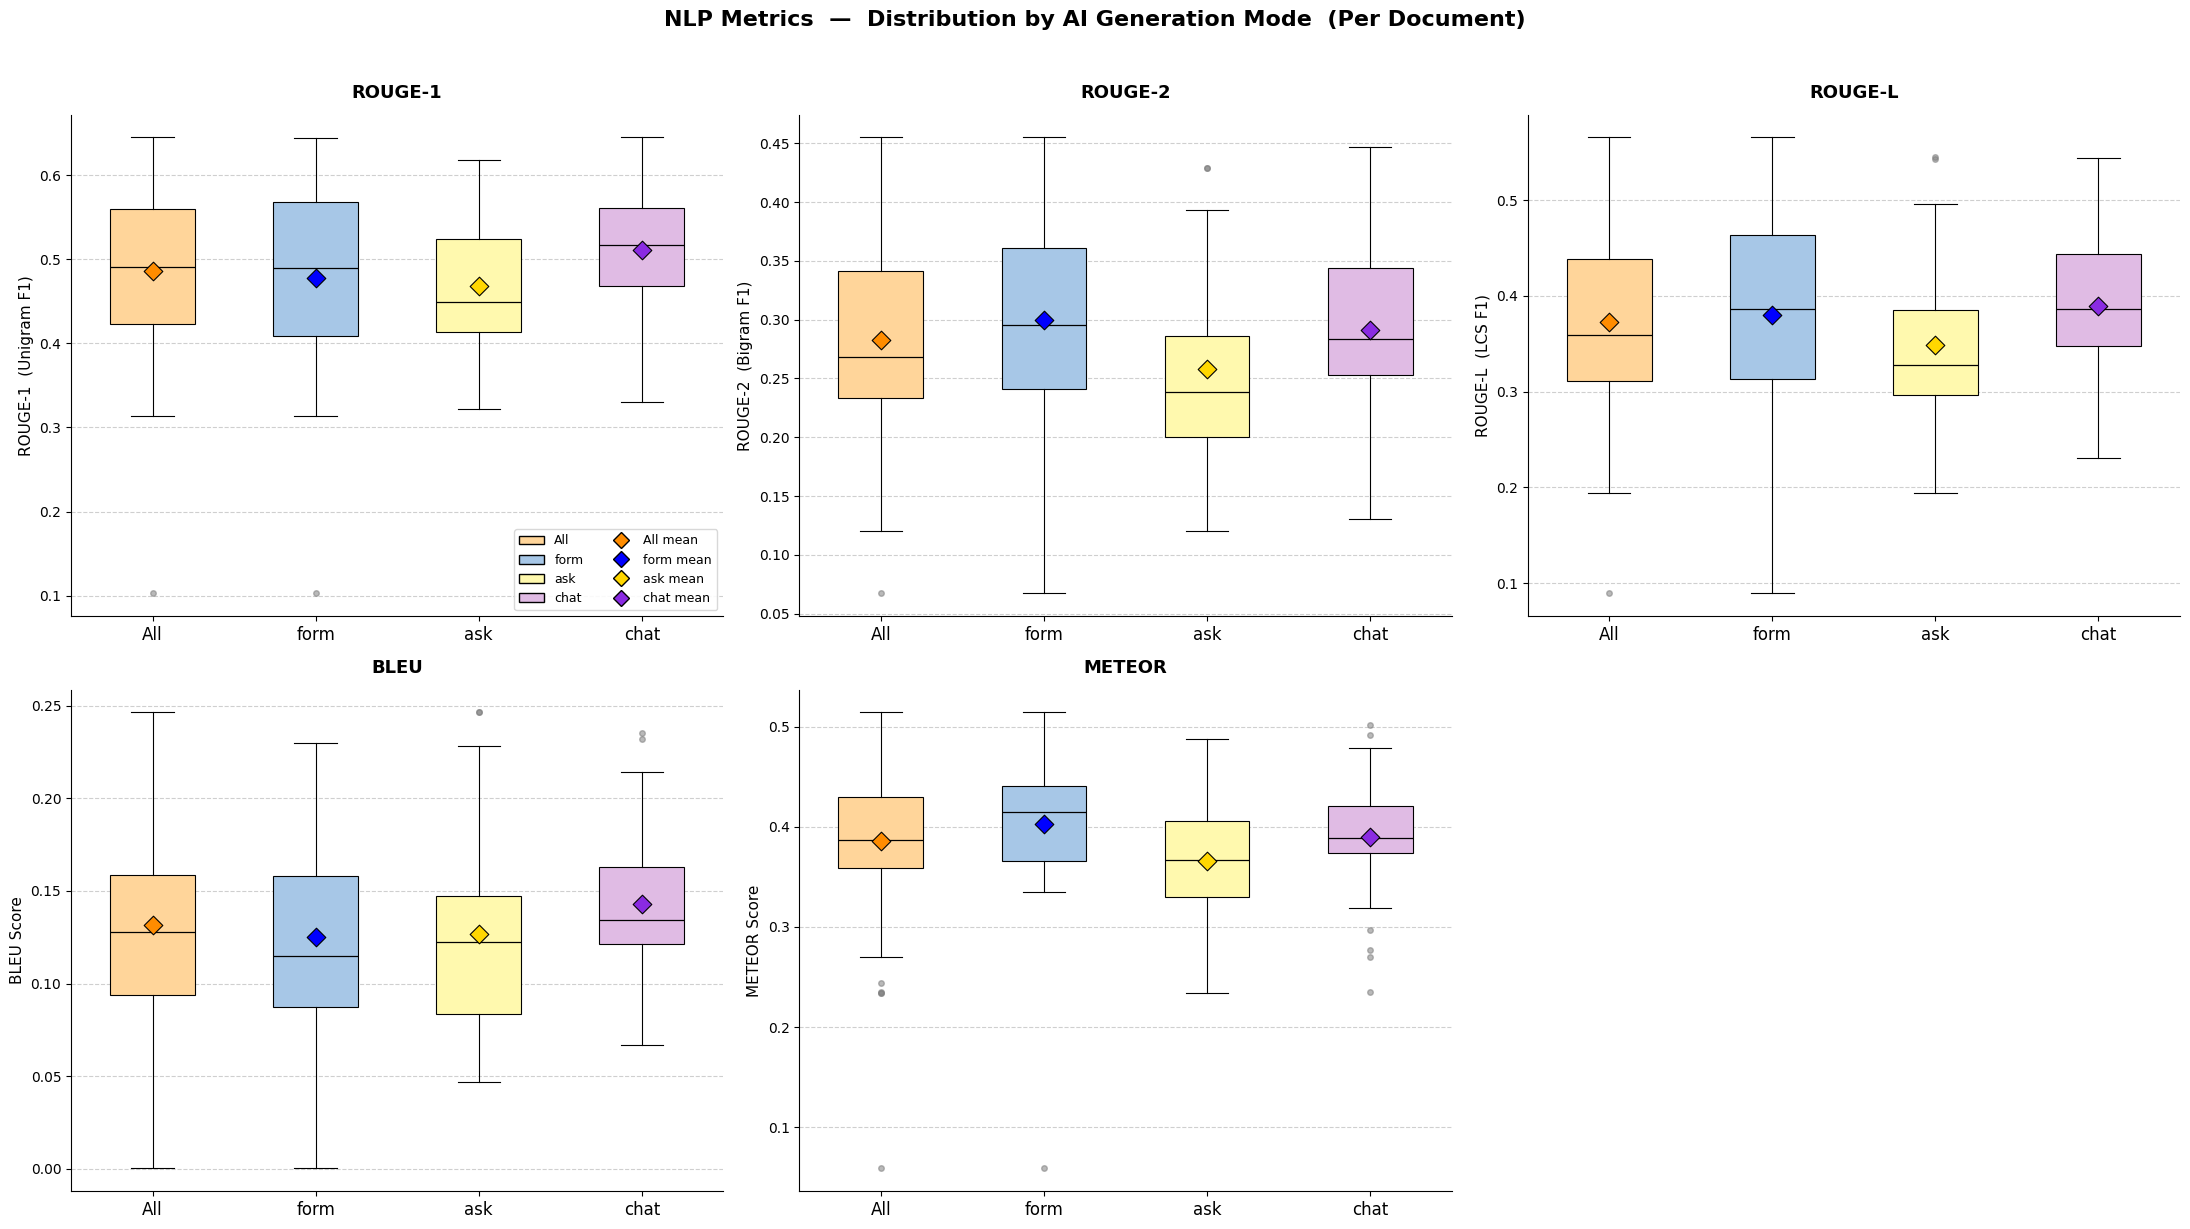

Saved → output/nlp_metrics_boxplot.png


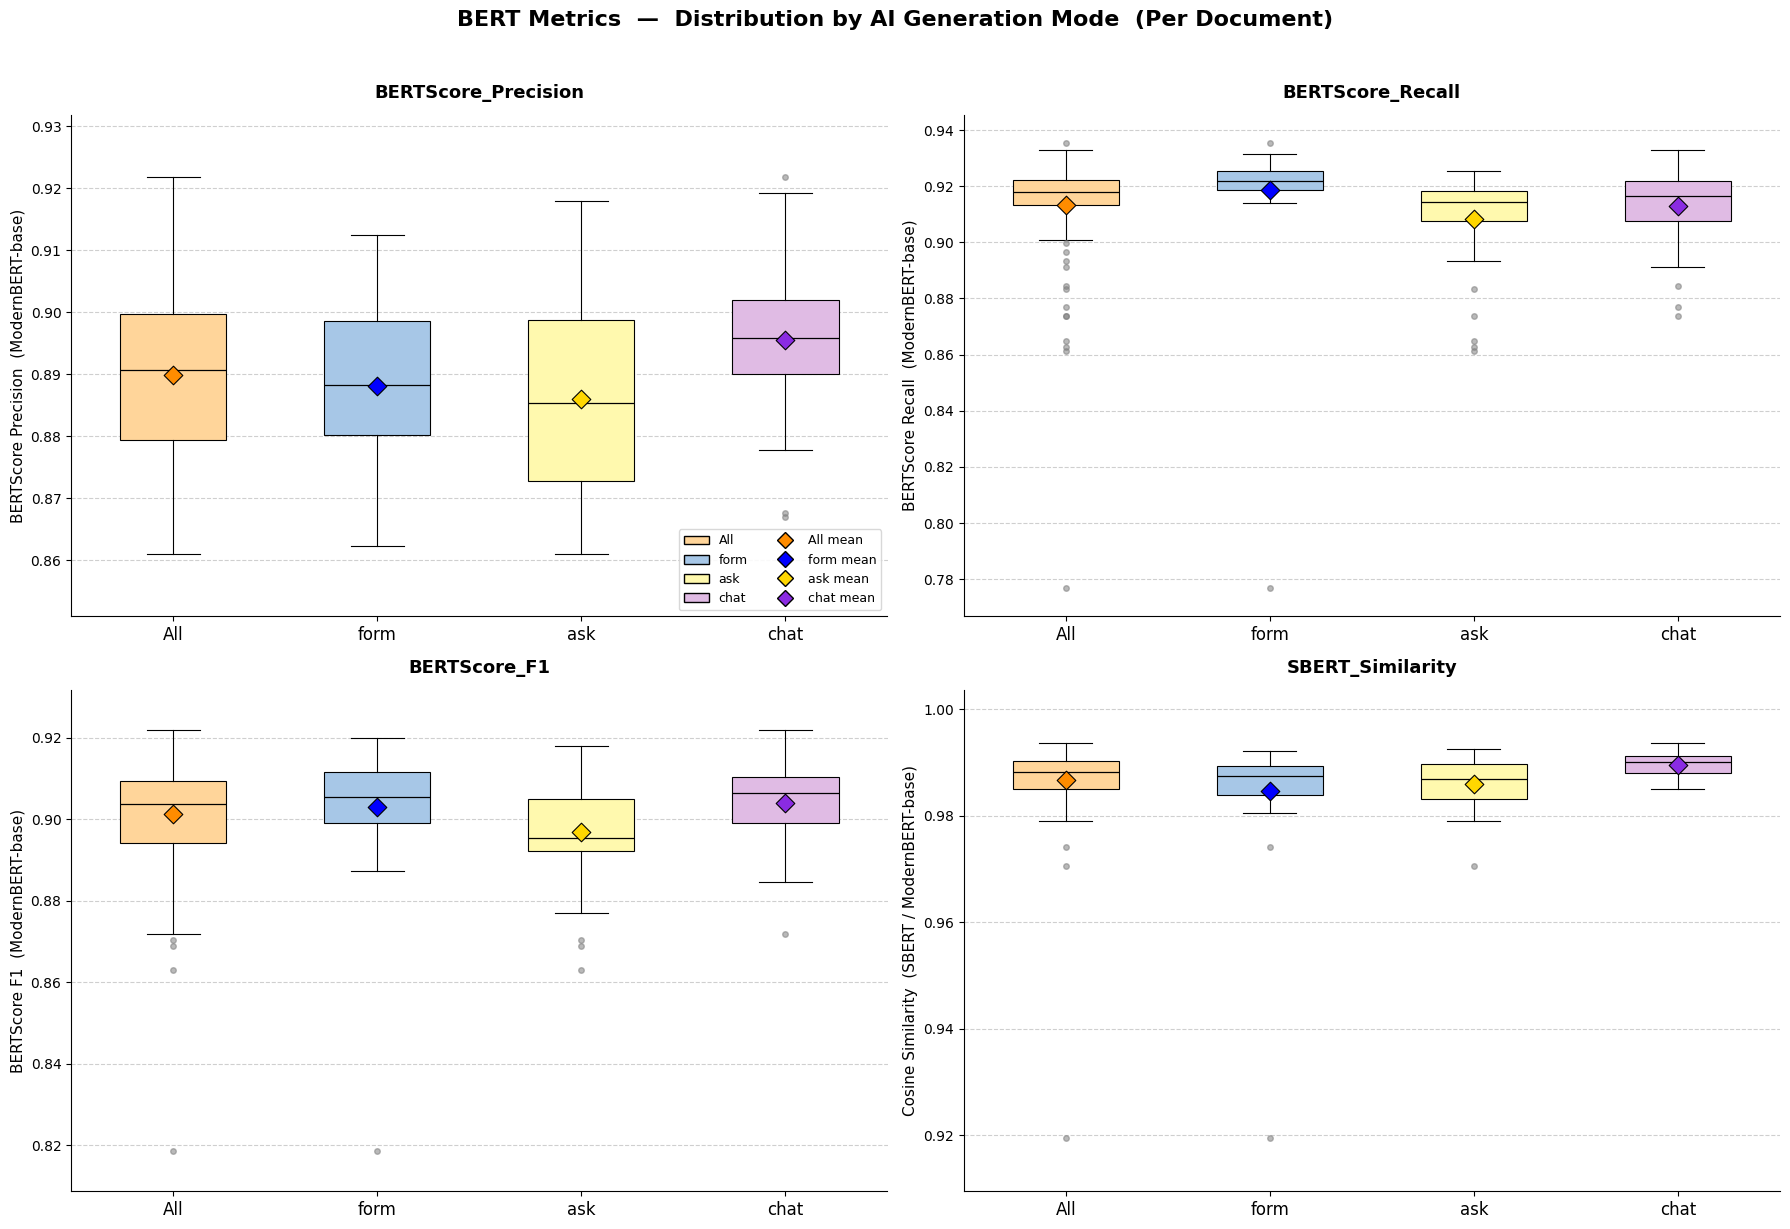

Saved → output/bert_metrics_boxplot.png


In [117]:
# ── Per-metric boxplots ────────────────────────────────────────────────────────
OUT = "output"

METRIC_META = [
    ("ROUGE-1",              "ROUGE-1  (Unigram F1)",                     (0.0, 1.0)),
    ("ROUGE-2",              "ROUGE-2  (Bigram F1)",                      (0.0, 1.0)),
    ("ROUGE-L",              "ROUGE-L  (LCS F1)",                         (0.0, 1.0)),
    ("BLEU",                 "BLEU Score",                                    None),
    ("METEOR",               "METEOR Score",                                   (0.0, 1.0)),
    ("BERTScore_Precision",  "BERTScore Precision  (ModernBERT-base)",        (0.85, 1.00)),
    ("BERTScore_Recall",     "BERTScore Recall  (ModernBERT-base)",           (0.85, 1.00)),
    ("BERTScore_F1",         "BERTScore F1  (ModernBERT-base)",               (0.85, 1.00)),
    ("SBERT_Similarity",     "Cosine Similarity  (SBERT / ModernBERT-base)",  (0.85, 1.00)),
]

NLP_METRICS  = METRIC_META[:5]   # BLEU, ROUGE-1/2/L, METEOR
BERT_METRICS = METRIC_META[5:]   # BERTScore P/R/F1, SBERT

GROUPS      = ["All",     "form",    "ask",     "chat"]
BOX_COLORS  = ["#FFD59A", "#A7C7E7", "#FFF9AE", "#E0BBE4"]
MEAN_COLORS = ["#FF8C00", "#0000FF", "#FFD700", "#8A2BE2"]


def _get_metric(metric: str, mode_key: str) -> np.ndarray:
    if mode_key == "All":
        return df_combined[metric].dropna().values
    df_m = mode_results.get(mode_key)
    if df_m is None or df_m.empty:
        return np.array([])
    return df_m[metric].dropna().values


def _draw_metric(ax, metric, ylabel, ylim, add_legend=False):
    group_data = [_get_metric(metric, g) for g in GROUPS]

    bp = ax.boxplot(
        group_data,
        positions=range(len(GROUPS)),
        widths=0.52,
        patch_artist=True,
        showfliers=True,
        medianprops=dict(color="black", linewidth=0.9),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8),
        boxprops=dict(linewidth=0.8),
        flierprops=dict(marker="o", markerfacecolor="grey",
                        markeredgecolor="grey", markersize=4, alpha=0.55),
    )

    for patch, box_col in zip(bp["boxes"], BOX_COLORS):
        patch.set_facecolor(box_col)
        patch.set_edgecolor("black")

    for i, (data, mean_col) in enumerate(zip(group_data, MEAN_COLORS)):
        if len(data) == 0:
            continue
        ax.scatter(i, np.mean(data), marker="D", s=90,
                   color=mean_col, edgecolors="black", linewidths=0.8, zorder=6)

    ax.set_xticks(range(len(GROUPS)))
    ax.set_xticklabels(GROUPS, fontsize=12)

    # Dynamic y-axis limits based on actual data range
    all_vals = np.concatenate([d for d in group_data if len(d) > 0])
    if len(all_vals) > 0:
        data_min, data_max = all_vals.min(), all_vals.max()
        data_range = data_max - data_min
        padding = max(data_range * 0.05, 0.01)
        ax.set_ylim(data_min - padding, data_max + padding)

    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(metric, fontsize=13, fontweight="bold", pad=12)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    box_patches = [
        mpatches.Patch(facecolor=bc, edgecolor="black", label=g)
        for g, bc in zip(GROUPS, BOX_COLORS)
    ]
    mean_handles = [
        plt.Line2D([0], [0], marker="D", color="w",
                   markerfacecolor=mc, markeredgecolor="black",
                   markersize=8, label=f"{g} mean")
        for g, mc in zip(GROUPS, MEAN_COLORS)
    ]
    if add_legend:
        ax.legend(handles=box_patches + mean_handles, loc="lower right",
                  fontsize=9, ncol=2, framealpha=0.88, edgecolor="lightgrey")


# ── PNG 1: NLP Metrics (BLEU · ROUGE-1/2/L · METEOR) — 2×3 grid ───────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

for i, (metric, ylabel, ylim) in enumerate(NLP_METRICS):
    _draw_metric(axes[i], metric, ylabel, ylim, add_legend=(i == 0))

fig.delaxes(axes[5])  # remove 6th empty slot

plt.suptitle("NLP Metrics  —  Distribution by AI Generation Mode  (Per Document)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
fname_nlp = f"{OUT}/nlp_metrics_boxplot.png"
plt.savefig(fname_nlp, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {fname_nlp}")


# ── PNG 2: BERT Metrics (Precision · Recall · F1 · SBERT) — 2×2 grid ──────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, (metric, ylabel, ylim) in enumerate(BERT_METRICS):
    _draw_metric(axes[i], metric, ylabel, ylim, add_legend=(i == 0))

plt.suptitle("BERT Metrics  —  Distribution by AI Generation Mode  (Per Document)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
fname_bert = f"{OUT}/bert_metrics_boxplot.png"
plt.savefig(fname_bert, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {fname_bert}")


## Per-Document Summaries — Best / Worst User IDs

Reload `document_results.csv` and append `best_id` / `worst_id` rows (using `user_id`, not the row index already stored in `highest_id`/`lowest_id`) to the existing summary CSVs.

In [118]:
# ── best_id / worst_id patch ─────────────────────────────────────────────────
# Previously patched the old summary_*.csv files with best_id/worst_id rows.
# Those files are no longer generated; best/worst IDs are now included directly
# in doc_nlp_summary.csv and doc_bert_summary.csv (Cell 13).
# This cell is intentionally left empty.


In [119]:
# ── Export: doc_nlp_summary.csv & doc_bert_summary.csv ──────────────────────
# Tidy per-metric summaries (min/q1/median/q3/max/mean/std/n + best/worst)
# across All, form, ask, chat groups, sourced from document_results.csv.

import pandas as pd

OUT = "output"

df_eval = pd.read_csv(f"{OUT}/document_results.csv")

NLP_METRICS  = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR"]
BERT_METRICS = ["BERTScore_Precision", "BERTScore_Recall", "BERTScore_F1",
                "SBERT_Similarity"]


def build_doc_summary(df: pd.DataFrame, metrics: list) -> pd.DataFrame:
    """
    For each metric compute descriptive stats + best/worst user_id across
    All rows and per-mode subsets.  Returns a wide DataFrame (rows = metrics).
    """
    groups = {"All": df, "form": df[df["ai_mode"] == "form"],
              "ask":  df[df["ai_mode"] == "ask"],
              "chat": df[df["ai_mode"] == "chat"]}

    rows = []
    for metric in metrics:
        row = {"metric": metric}
        for grp_name, grp_df in groups.items():
            s = grp_df[metric]
            prefix = grp_name
            row[f"{prefix}_min"]        = round(s.min(),  4)
            row[f"{prefix}_q1"]         = round(s.quantile(0.25), 4)
            row[f"{prefix}_median"]     = round(s.median(), 4)
            row[f"{prefix}_q3"]         = round(s.quantile(0.75), 4)
            row[f"{prefix}_max"]        = round(s.max(),  4)
            row[f"{prefix}_mean"]       = round(s.mean(), 4)
            row[f"{prefix}_std"]        = round(s.std(),  4)
            row[f"{prefix}_n"]          = int(s.count())
            row[f"{prefix}_best_id"]    = grp_df.loc[grp_df[metric].idxmax(), "user_id"]
            row[f"{prefix}_best_score"] = round(grp_df[metric].max(), 4)
            row[f"{prefix}_worst_id"]   = grp_df.loc[grp_df[metric].idxmin(), "user_id"]
            row[f"{prefix}_worst_score"]= round(grp_df[metric].min(), 4)
        rows.append(row)
    return pd.DataFrame(rows)


df_doc_nlp  = build_doc_summary(df_eval, NLP_METRICS)
df_doc_bert = build_doc_summary(df_eval, BERT_METRICS)

df_doc_nlp.to_csv(f"{OUT}/doc_nlp_summary.csv",  index=False)
df_doc_bert.to_csv(f"{OUT}/doc_bert_summary.csv", index=False)

print(f"Saved {OUT}/doc_nlp_summary.csv  — {len(df_doc_nlp)} rows")
print(f"Saved {OUT}/doc_bert_summary.csv — {len(df_doc_bert)} rows")
display(df_doc_nlp[["metric", "All_mean", "form_mean", "ask_mean", "chat_mean",
                     "All_best_id", "All_worst_id"]].round(4))
display(df_doc_bert[["metric", "All_mean", "form_mean", "ask_mean", "chat_mean",
                      "All_best_id", "All_worst_id"]].round(4))


Saved output/doc_nlp_summary.csv  — 5 rows
Saved output/doc_bert_summary.csv — 4 rows


,metric,All_mean,form_mean,ask_mean,chat_mean,All_best_id,All_worst_id
0,BLEU,0.1317,0.1252,0.1267,0.1430,IOL1223,UTP0442
1,ROUGE-1,0.4854,0.4775,0.4675,0.5106,EHN0215,UTP0442
2,ROUGE-2,0.2830,0.2997,0.2577,0.2913,aea2442,UTP0442
3,ROUGE-L,0.3727,0.3802,0.3484,0.3892,aea2442,UTP0442
4,METEOR,0.3863,0.4031,0.3654,0.3902,EHN0215,UTP0442


,metric,All_mean,form_mean,ask_mean,chat_mean,All_best_id,All_worst_id
0,BERTScore_Precision,0.8899,0.8880,0.8860,0.8954,IOL1223,thg1620
1,BERTScore_Recall,0.9133,0.9187,0.9082,0.9130,EII0925,UTP0442
2,BERTScore_F1,0.9013,0.9029,0.8968,0.9041,EHN0215,UTP0442
3,SBERT_Similarity,0.9867,0.9846,0.9860,0.9895,NAN277,UTP0442


## Chapterwise Analysis

Each AI-generated document is split into its 6 canonical GDPR ROPA chapters and scored against the corresponding reference chapter. This reveals which parts of the ROPA structure participants handled well vs. poorly across the three interaction modes.

**6 canonical chapters (German):**
1. Verantwortliche Stelle und Kontaktdaten
2. Zwecke und Rechtsgrundlagen der Verarbeitung
3. Kategorien personenbezogener Daten und Datenquellen
4. Betroffene Personen und Empfänger
5. Aufbewahrungsfristen und Löschung
6. Technische und organisatorische Maßnahmen

In [120]:
import re
import difflib

CANONICAL_CHAPTERS = [
    "Verantwortliche Stelle und Kontaktdaten",
    "Zwecke und Rechtsgrundlagen der Verarbeitung",
    "Kategorien personenbezogener Daten und Datenquellen",
    "Betroffene Personen und Empfänger",
    "Aufbewahrungsfristen und Löschung",
    "Technische und organisatorische Maßnahmen",
]

CH_SHORT = [f"Ch{i+1}" for i in range(len(CANONICAL_CHAPTERS))]
CH_LABEL = dict(zip(CANONICAL_CHAPTERS, CH_SHORT))


def _strip_number(header: str) -> str:
    """Remove leading numeric prefix, e.g. '1. ' or '3.2 '."""
    return re.sub(r'^\d+[\.,]?\d*[\s.]+', '', header).strip()


def _is_sub_chapter(header: str) -> bool:
    """True for sub-chapter headings like '3.2 Datenquellen'."""
    return bool(re.match(r'^\d+\.\d+', header.strip()))


def fuzzy_match_chapter(
    header: str,
    canonical_list: list[str] = CANONICAL_CHAPTERS,
    threshold: float = 0.6,
) -> str | None:
    """
    Map an extracted section header to the closest canonical chapter name
    using difflib SequenceMatcher ratio.  Returns the matched canonical name
    or None if no match exceeds *threshold*.
    """
    h = _strip_number(header)
    m = difflib.get_close_matches(h, canonical_list, n=1, cutoff=threshold)
    return m[0] if m else None


def extract_chapters_markdown(text: str) -> dict[str, str]:
    """
    Split a markdown ROPA document into its H2 sections.

    Steps:
      1. Strip code-fence wrappers (```markdown … ```).
      2. Remove the metadata footer (lines after the last '---' separator).
      3. Find all ``## …`` headings, skipping sub-chapter headings like '3.2 …'.
      4. Return {raw_header: section_content} preserving document order.
    """
    text = text.strip()
    # Strip code fences
    if text.startswith('```'):
        text = text[text.index('\n') + 1:]
    if text.endswith('```'):
        text = text[:text.rindex('```')]

    # Remove metadata footer — everything from the last bare '---' onward
    lines = text.split('\n')
    for i in range(len(lines) - 1, -1, -1):
        if lines[i].strip() == '---':
            lines = lines[:i]
            break
    text = '\n'.join(lines)

    # Find H2 headings, excluding sub-chapters
    pattern = re.compile(r'^## (.+)', re.MULTILINE)
    matches = [
        m for m in pattern.finditer(text)
        if not _is_sub_chapter(m.group(1).strip())
    ]

    chapters: dict[str, str] = {}
    for idx, match in enumerate(matches):
        header = match.group(1).strip()
        start  = match.end()
        end    = matches[idx + 1].start() if idx + 1 < len(matches) else len(text)
        chapters[header] = text[start:end].strip()
    return chapters


def extract_reference_chapters(
    reference_text: str,
    canonical_list: list[str] = CANONICAL_CHAPTERS,
) -> dict[str, str]:
    """
    Split the plain-text reference (no markdown headings) into sections.

    Strategy: scan for lines that look like section headers — short, non-empty,
    not starting with a bullet or digit, and not sub-section labels (e.g. '3.1 …').
    Fuzzy-match each candidate to the canonical list; fall back to positional
    order if fewer than 4 candidates are found.
    """
    # Strip the metadata footer
    lines = reference_text.split('\n')
    for i in range(len(lines) - 1, -1, -1):
        if lines[i].strip() == '---':
            lines = lines[:i]
            break
    text = '\n'.join(lines)

    # Heuristic: a header line is short (<= 70 chars), non-empty, does not
    # start with a bullet ('•'), a digit-dot (sub-section like '2.1'), or
    # a '*' / '#'. We also skip the document title (first two non-empty lines).
    all_lines = text.split('\n')
    header_indices = []
    skipped_titles = 0
    for i, line in enumerate(all_lines):
        s = line.strip()
        if not s:
            continue
        if s.startswith(('•', '*', '#', '-')):
            continue
        if re.match(r'^\d+\.\d+', s):
            continue  # sub-section label
        if len(s) > 70:
            continue  # too long to be a heading
        if skipped_titles < 2:
            skipped_titles += 1
            continue  # skip document title lines
        # Check if it fuzzy-matches any canonical chapter
        match = difflib.get_close_matches(s, canonical_list, n=1, cutoff=0.35)
        if match:
            header_indices.append(i)

    # Fallback: if we can't find enough headers, use positional line scanning
    if len(header_indices) < 4:
        # Use the canonical chapter names directly as keys and split by blank lines
        # between major paragraphs — simple positional split
        paragraphs = [p.strip() for p in re.split(r'\n{2,}', text) if p.strip()]
        # Skip title paragraphs (first 1-2 short ones)
        content_paragraphs = [p for p in paragraphs if len(p) > 40]
        result = {}
        for i, c in enumerate(canonical_list):
            result[c] = content_paragraphs[i] if i < len(content_paragraphs) else ""
        return result

    # Build sections from detected header lines
    sections_raw = {}
    for idx, line_i in enumerate(header_indices):
        header = all_lines[line_i].strip()
        next_line_i = header_indices[idx + 1] if idx + 1 < len(header_indices) else len(all_lines)
        content_lines = all_lines[line_i + 1:next_line_i]
        sections_raw[header] = '\n'.join(content_lines).strip()

    # Fuzzy-match raw headers → canonical, with positional fallback for misses
    result = {}
    used_headers: set[str] = set()
    for canonical in canonical_list:
        best_score, best_header = 0.0, None
        for h in sections_raw:
            if h in used_headers:
                continue
            ratio = difflib.SequenceMatcher(None, h.lower(), canonical.lower()).ratio()
            if ratio > best_score:
                best_score, best_header = ratio, h
        if best_score >= 0.35 and best_header is not None:
            result[canonical] = sections_raw[best_header]
            used_headers.add(best_header)

    # Positional fallback for any remaining unmatched canonical chapters
    unmatched_headers   = [h for h in sections_raw if h not in used_headers]
    missing_canonicals  = [c for c in canonical_list if c not in result]
    for i, canonical in enumerate(missing_canonicals):
        if i < len(unmatched_headers):
            result[canonical] = sections_raw[unmatched_headers[i]]

    return result


def map_doc_chapters_to_canonical(
    raw_dict: dict[str, str],
    canonical_list: list[str] = CANONICAL_CHAPTERS,
) -> dict[str, str]:
    """
    Map extracted document chapters to canonical names.

    Uses best-fit SequenceMatcher assignment (threshold 0.45), then falls back
    to positional order for any canonical chapter that remains unmatched.
    Missing chapters (genuinely absent from the document) get empty string.
    """
    headers_in_order = list(raw_dict.keys())
    result: dict[str, str] = {}
    used_headers: set[str] = set()

    for canonical in canonical_list:
        best_score, best_header = 0.0, None
        for h in headers_in_order:
            if h in used_headers:
                continue
            h_clean = _strip_number(h)
            ratio = difflib.SequenceMatcher(None, h_clean.lower(), canonical.lower()).ratio()
            if ratio > best_score:
                best_score, best_header = ratio, h
        if best_score >= 0.45 and best_header is not None:
            result[canonical] = raw_dict[best_header]
            used_headers.add(best_header)

    # Positional fallback for remaining canonical chapters
    unmatched_headers  = [h for h in headers_in_order if h not in used_headers]
    missing_canonicals = [c for c in canonical_list if c not in result]
    for i, canonical in enumerate(missing_canonicals):
        if i < len(unmatched_headers):
            result[canonical] = raw_dict[unmatched_headers[i]]
            used_headers.add(unmatched_headers[i])
        else:
            result[canonical] = ""  # genuinely missing chapter → score as 0

    return result


# ── Parse reference chapters once ─────────────────────────────────────────
ref_chapters = extract_reference_chapters(reference_text)
print("Reference chapters extracted:")
for ch, content in ref_chapters.items():
    print(f"  {ch!r}: {len(content)} chars")


Reference chapters extracted:
  'Verantwortliche Stelle und Kontaktdaten': 343 chars
  'Zwecke und Rechtsgrundlagen der Verarbeitung': 23 chars
  'Kategorien personenbezogener Daten und Datenquellen': 32 chars
  'Betroffene Personen und Empfänger': 35 chars
  'Aufbewahrungsfristen und Löschung': 165 chars
  'Technische und organisatorische Maßnahmen': 709 chars


In [121]:
from sentence_transformers import SentenceTransformer
import numpy as np
import torch.nn.functional as F

# ── Load MiniLM (chapter-level only; NOT used for whole-document scoring) ──
MINILM_NAME = "sentence-transformers/all-MiniLM-L6-v2"
print(f"Loading SentenceTransformer: {MINILM_NAME} …")
sbert_minilm = SentenceTransformer(MINILM_NAME, device=DEVICE)
sbert_minilm.max_seq_length = 384
print(f"Max seq length : {sbert_minilm.max_seq_length}")
print(f"Embedding dim  : {sbert_minilm.get_sentence_embedding_dimension()}")

# ── Pre-encode reference chapters with both models ─────────────────────────
ref_chapter_texts = [ref_chapters.get(ch, "") for ch in CANONICAL_CHAPTERS]

# ModernBERT (sbert_model already loaded in cell 6)
ref_ch_emb_modernbert = sbert_model.encode(
    ref_chapter_texts,
    batch_size=1,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=False,
)  # shape: (6, hidden_dim)

# MiniLM
ref_ch_emb_minilm = sbert_minilm.encode(
    ref_chapter_texts,
    batch_size=6,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=False,
)  # shape: (6, hidden_dim)

print(f"Reference chapter embeddings (ModernBERT): {ref_ch_emb_modernbert.shape}")
print(f"Reference chapter embeddings (MiniLM)    : {ref_ch_emb_minilm.shape}")


Loading SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2 …


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 17690.24it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Max seq length : 384
Embedding dim  : 384
Reference chapter embeddings (ModernBERT): (6, 768)
Reference chapter embeddings (MiniLM)    : (6, 384)


In [122]:
from tqdm.auto import tqdm
import torch

CHAPTER_METRIC_COLS = [
    "BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR",
    "BERTScore_Precision", "BERTScore_Recall", "BERTScore_F1",
    "SBERT_ModernBERT", "SBERT_MiniLM",
]


def compute_chapter_metrics_for_doc(
    doc_chapters: dict[str, str],
    ref_ch_emb_mb: np.ndarray,
    ref_ch_emb_ml: np.ndarray,
) -> list[dict]:
    """
    Compute all metrics for one document's 6 canonical chapters.
    Returns a list of 6 dicts (one per chapter) with metric scores.
    """
    rows = []
    for ch_idx, canonical in enumerate(CANONICAL_CHAPTERS):
        cand_text = doc_chapters.get(canonical, "")
        ref_text  = ref_chapters.get(canonical, "")

        row = {"chapter": canonical}

        if not cand_text.strip() or not ref_text.strip():
            # Missing chapter → zero scores for all metrics
            for col in CHAPTER_METRIC_COLS:
                row[col] = 0.0
            rows.append(row)
            continue

        # ── Lexical metrics (reuse existing functions) ─────────────────────
        try:
            b = bleu_metric.compute(predictions=[cand_text], references=[[ref_text]])
            row["BLEU"] = b["bleu"]
        except Exception:
            row["BLEU"] = 0.0

        r = rouge_metric.compute(predictions=[cand_text], references=[ref_text])
        row["ROUGE-1"] = r["rouge1"]
        row["ROUGE-2"] = r["rouge2"]
        row["ROUGE-L"] = r["rougeL"]

        m = meteor_metric.compute(predictions=[cand_text], references=[ref_text])
        row["METEOR"] = m["meteor"]

        # ── BERTScore (ModernBERT, batch_size=1 for short chapter strings) ───
        prec_list, rec_list, f1_list = compute_bertscore(
            [cand_text], ref_text, batch_size=1
        )
        row["BERTScore_Precision"] = prec_list[0]
        row["BERTScore_Recall"]    = rec_list[0]
        row["BERTScore_F1"]        = f1_list[0]

        # ── SBERT ModernBERT ──────────────────────────────────────────────
        cand_emb_mb = sbert_model.encode(
            [cand_text],
            batch_size=1,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=False,
        )  # (1, dim)
        sim_mb = float((cand_emb_mb @ ref_ch_emb_mb[ch_idx:ch_idx+1].T).squeeze())
        row["SBERT_ModernBERT"] = sim_mb

        # ── SBERT MiniLM ─────────────────────────────────────────────────
        cand_emb_ml = sbert_minilm.encode(
            [cand_text],
            batch_size=1,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=False,
        )  # (1, dim)
        sim_ml = float((cand_emb_ml @ ref_ch_emb_ml[ch_idx:ch_idx+1].T).squeeze())
        row["SBERT_MiniLM"] = sim_ml

        rows.append(row)
    return rows


# ── Build lookup: id → document text (from df_all loaded in cell 2) ──────
_doc_lookup = df_all.set_index("id")["document"].to_dict()

# ── Run over all documents ─────────────────────────────────────────────────
all_chapter_rows = []

for _, doc_row in tqdm(df_eval.iterrows(), total=len(df_eval), desc="Documents"):
    doc_text     = str(_doc_lookup.get(doc_row["id"], ""))
    raw_chapters = extract_chapters_markdown(doc_text)
    doc_chapters = map_doc_chapters_to_canonical(raw_chapters)

    ch_rows = compute_chapter_metrics_for_doc(
        doc_chapters, ref_ch_emb_modernbert, ref_ch_emb_minilm
    )
    for ch_row in ch_rows:
        ch_row["id"]      = doc_row["id"]
        ch_row["user_id"] = doc_row["user_id"]
        ch_row["ai_mode"] = doc_row["ai_mode"]
        all_chapter_rows.append(ch_row)

df_chapters = pd.DataFrame(all_chapter_rows)[
    ["id", "user_id", "ai_mode", "chapter"] + CHAPTER_METRIC_COLS
]

df_chapters.to_csv(f"{OUT}/chapter_results.csv", index=False)
print(f"\nSaved {OUT}/chapter_results.csv  — {len(df_chapters)} rows")
print(f"Shape: {df_chapters.shape}")
display(df_chapters.head(12))


Documents: 100%|██████████| 115/115 [01:25<00:00,  1.34it/s]


Saved output/chapter_results.csv  — 690 rows
Shape: (690, 14)


,id,user_id,ai_mode,chapter,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,METEOR,BERTScore_Precision,BERTScore_Recall,BERTScore_F1,SBERT_ModernBERT,SBERT_MiniLM
0,5,EHN0215,ask,Verantwortliche Stelle und Kontaktdaten,0.235307,0.573913,0.407080,0.573913,0.569049,0.856703,0.888652,0.872385,0.976369,0.753277
1,5,EHN0215,ask,Zwecke und Rechtsgrundlagen der Verarbeitung,0.000000,0.021390,0.010811,0.021390,0.016667,0.560255,0.689687,0.618270,0.738934,0.277838
2,5,EHN0215,ask,Kategorien personenbezogener Daten und Datenqu...,0.000000,0.025974,0.013158,0.025974,0.017794,0.633595,0.842298,0.723191,0.833485,0.377747
3,5,EHN0215,ask,Betroffene Personen und Empfänger,0.000000,0.026201,0.008811,0.026201,0.044776,0.647686,0.820087,0.723762,0.848807,0.380258
4,5,EHN0215,ask,Aufbewahrungsfristen und Löschung,0.000000,0.081481,0.037313,0.066667,0.171181,0.737311,0.860194,0.794027,0.904858,0.383321
5,5,EHN0215,ask,Technische und organisatorische Maßnahmen,0.137587,0.482759,0.295652,0.379310,0.453329,0.869326,0.901415,0.885080,0.975089,0.822641
6,7,RIT1851,ask,Verantwortliche Stelle und Kontaktdaten,0.141114,0.516667,0.305085,0.350000,0.419237,0.846066,0.872230,0.858949,0.974810,0.548826
7,7,RIT1851,ask,Zwecke und Rechtsgrundlagen der Verarbeitung,0.000000,0.024390,0.012346,0.024390,0.021834,0.554237,0.659464,0.602289,0.719414,0.272279
8,7,RIT1851,ask,Kategorien personenbezogener Daten und Datenqu...,0.000000,0.025641,0.012987,0.025641,0.019011,0.653846,0.837973,0.734546,0.852386,0.363110
9,7,RIT1851,ask,Betroffene Personen und Empfänger,0.000000,0.070796,0.018018,0.070796,0.101523,0.674600,0.845091,0.750282,0.858736,0.339303


In [123]:
# ── Per-mode, per-chapter summary ────────────────────────────────────────

def build_chapter_summary(df: pd.DataFrame, metric_cols: list[str]) -> pd.DataFrame:
    """
    For each (ai_mode, chapter) group compute mean, std, best_id, worst_id
    for every metric.  Returns a tidy DataFrame.
    """
    rows = []
    for (mode, chapter), grp in df.groupby(["ai_mode", "chapter"], sort=False):
        row = {"ai_mode": mode, "chapter": chapter}
        for col in metric_cols:
            row[f"{col}_mean"] = grp[col].mean()
            row[f"{col}_std"]  = grp[col].std()
            row[f"{col}_best_id"]  = grp.loc[grp[col].idxmax(), "user_id"] if len(grp) > 0 else None
            row[f"{col}_worst_id"] = grp.loc[grp[col].idxmin(), "user_id"] if len(grp) > 0 else None
        rows.append(row)
    return pd.DataFrame(rows)


df_ch_summary_mode = build_chapter_summary(df_chapters, CHAPTER_METRIC_COLS)
# Ensure canonical chapter order
df_ch_summary_mode["chapter"] = pd.Categorical(
    df_ch_summary_mode["chapter"], categories=CANONICAL_CHAPTERS, ordered=True
)
df_ch_summary_mode = df_ch_summary_mode.sort_values(["ai_mode", "chapter"]).reset_index(drop=True)


# Display mean columns only for readability
mean_cols = ["ai_mode", "chapter"] + [f"{c}_mean" for c in CHAPTER_METRIC_COLS]
display(df_ch_summary_mode[mean_cols].round(4))


,ai_mode,chapter,BLEU_mean,ROUGE-1_mean,ROUGE-2_mean,ROUGE-L_mean,METEOR_mean,BERTScore_Precision_mean,BERTScore_Recall_mean,BERTScore_F1_mean,SBERT_ModernBERT_mean,SBERT_MiniLM_mean
0,ask,Verantwortliche Stelle und Kontaktdaten,0.1975,0.6026,0.4262,0.5715,0.5041,0.8614,0.8868,0.8739,0.9764,0.7309
1,ask,Zwecke und Rechtsgrundlagen der Verarbeitung,0.0000,0.0312,0.0120,0.0296,0.0332,0.5698,0.6665,0.6139,0.7362,0.3247
2,ask,Kategorien personenbezogener Daten und Datenqu...,0.0000,0.0796,0.0518,0.0796,0.1359,0.6893,0.8489,0.7604,0.8679,0.4498
3,ask,Betroffene Personen und Empfänger,0.0079,0.0910,0.0574,0.0910,0.2001,0.6992,0.8375,0.7617,0.8715,0.4122
4,ask,Aufbewahrungsfristen und Löschung,0.0221,0.2089,0.0847,0.1809,0.2405,0.8153,0.8783,0.8451,0.9448,0.4643
5,ask,Technische und organisatorische Maßnahmen,0.0680,0.3217,0.1585,0.2395,0.2728,0.8358,0.8590,0.8469,0.9466,0.6823
6,chat,Verantwortliche Stelle und Kontaktdaten,0.1661,0.5585,0.3651,0.5107,0.4526,0.8548,0.8789,0.8666,0.9749,0.6620
7,chat,Zwecke und Rechtsgrundlagen der Verarbeitung,0.0000,0.0243,0.0080,0.0242,0.0153,0.5681,0.6619,0.6112,0.7320,0.2871
8,chat,Kategorien personenbezogener Daten und Datenqu...,0.0000,0.0705,0.0360,0.0705,0.1007,0.6978,0.8472,0.7650,0.8712,0.4545
9,chat,Betroffene Personen und Empfänger,0.0136,0.1234,0.0887,0.1234,0.2698,0.7123,0.8361,0.7689,0.8723,0.5020


In [124]:
# ── Aggregated chapter summary (across all modes) ────────────────────────

rows_overall = []
for chapter, grp in df_chapters.groupby("chapter", sort=False):
    row = {"chapter": chapter}
    for col in CHAPTER_METRIC_COLS:
        row[f"{col}_mean"] = grp[col].mean()
        row[f"{col}_std"]  = grp[col].std()
        row[f"{col}_best_id"]  = grp.loc[grp[col].idxmax(), "user_id"] if len(grp) > 0 else None
        row[f"{col}_worst_id"] = grp.loc[grp[col].idxmin(), "user_id"] if len(grp) > 0 else None
    rows_overall.append(row)

df_ch_summary_overall = pd.DataFrame(rows_overall)
df_ch_summary_overall["chapter"] = pd.Categorical(
    df_ch_summary_overall["chapter"], categories=CANONICAL_CHAPTERS, ordered=True
)
df_ch_summary_overall = df_ch_summary_overall.sort_values("chapter").reset_index(drop=True)


mean_cols_ov = ["chapter"] + [f"{c}_mean" for c in CHAPTER_METRIC_COLS]
display(df_ch_summary_overall[mean_cols_ov].round(4))


,chapter,BLEU_mean,ROUGE-1_mean,ROUGE-2_mean,ROUGE-L_mean,METEOR_mean,BERTScore_Precision_mean,BERTScore_Recall_mean,BERTScore_F1_mean,SBERT_ModernBERT_mean,SBERT_MiniLM_mean
0,Verantwortliche Stelle und Kontaktdaten,0.1790,0.5663,0.3823,0.5295,0.4669,0.8572,0.8799,0.8683,0.9747,0.6826
1,Zwecke und Rechtsgrundlagen der Verarbeitung,0.0000,0.0277,0.0112,0.0270,0.0270,0.5611,0.6604,0.6064,0.7283,0.2956
2,Kategorien personenbezogener Daten und Datenqu...,0.0000,0.0683,0.0407,0.0683,0.1045,0.6801,0.8412,0.7518,0.8586,0.4245
3,Betroffene Personen und Empfänger,0.0115,0.1010,0.0721,0.1010,0.2218,0.6934,0.8342,0.7569,0.8629,0.4347
4,Aufbewahrungsfristen und Löschung,0.0427,0.2566,0.1283,0.2257,0.3091,0.8159,0.8809,0.8469,0.9400,0.5112
5,Technische und organisatorische Maßnahmen,0.0785,0.3255,0.1726,0.2521,0.2882,0.8394,0.8728,0.8555,0.9545,0.6974


In [125]:
# ── Combined comparison: whole-document score vs. mean chapter score ─────
# Rows: each metric (+ SBERT_MiniLM as chapter-only)
# Columns: metric | doc_score (mean) | chapter_avg (mean of 6 chapter means) | difference

def build_comparison_table(
    df_doc: pd.DataFrame,
    df_ch: pd.DataFrame,
    label: str,
) -> pd.DataFrame:
    """Build doc-vs-chapter comparison for one subset (mode or all)."""
    records = []

    # Metrics that exist in both doc-level and chapter-level
    shared_metrics = [
        ("BLEU",               "BLEU"),
        ("ROUGE-1",            "ROUGE-1"),
        ("ROUGE-2",            "ROUGE-2"),
        ("ROUGE-L",            "ROUGE-L"),
        ("METEOR",             "METEOR"),
        ("BERTScore_Precision", "BERTScore_Precision"),
        ("BERTScore_Recall",   "BERTScore_Recall"),
        ("BERTScore_F1",       "BERTScore_F1"),
        ("SBERT_Similarity",   "SBERT_ModernBERT"),  # whole-doc SBERT vs chapter SBERT ModernBERT
    ]
    for doc_col, ch_col in shared_metrics:
        doc_mean = df_doc[doc_col].mean() if doc_col in df_doc.columns else float('nan')
        ch_mean  = df_ch[ch_col].mean()  if ch_col  in df_ch.columns  else float('nan')
        records.append({
            "subset":       label,
            "metric":       doc_col,
            "doc_score":    round(doc_mean, 4),
            "chapter_avg":  round(ch_mean,  4),
            "difference":   round(doc_mean - ch_mean, 4),
        })

    # SBERT_MiniLM — chapter-only (no whole-doc equivalent)
    if "SBERT_MiniLM" in df_ch.columns:
        records.append({
            "subset":      label,
            "metric":      "SBERT_MiniLM",
            "doc_score":   float('nan'),
            "chapter_avg": round(df_ch["SBERT_MiniLM"].mean(), 4),
            "difference":  float('nan'),
        })

    return pd.DataFrame(records)


MODES_ALL = sorted(df_eval["ai_mode"].unique())
comparison_parts = []

# Overall
comparison_parts.append(
    build_comparison_table(df_eval, df_chapters, label="overall")
)

# Per mode
for mode in MODES_ALL:
    comparison_parts.append(
        build_comparison_table(
            df_eval[df_eval["ai_mode"] == mode],
            df_chapters[df_chapters["ai_mode"] == mode],
            label=mode,
        )
    )

df_comparison = pd.concat(comparison_parts, ignore_index=True)
df_comparison_pivot = df_comparison.pivot(
    index="metric", columns="subset", values=["doc_score", "chapter_avg", "difference"]
)
df_comparison_T = df_comparison_pivot.T

# Display per subset
for subset, grp in df_comparison.groupby("subset", sort=False):
    print(f"\n── {subset} ──")
    display(grp[["metric", "doc_score", "chapter_avg", "difference"]].reset_index(drop=True))



── overall ──


,metric,doc_score,chapter_avg,difference
0,BLEU,0.1317,0.0519,0.0798
1,ROUGE-1,0.4854,0.2242,0.2612
2,ROUGE-2,0.2830,0.1345,0.1485
3,ROUGE-L,0.3727,0.2006,0.1721
4,METEOR,0.3863,0.2362,0.1501
5,BERTScore_Precision,0.8899,0.7412,0.1487
6,BERTScore_Recall,0.9133,0.8282,0.0850
7,BERTScore_F1,0.9013,0.7809,0.1204
8,SBERT_Similarity,0.9867,0.8865,0.1002
9,SBERT_MiniLM,NaN,0.5077,NaN



── ask ──


,metric,doc_score,chapter_avg,difference
0,BLEU,0.1267,0.0492,0.0775
1,ROUGE-1,0.4675,0.2225,0.2450
2,ROUGE-2,0.2577,0.1318,0.1260
3,ROUGE-L,0.3484,0.1987,0.1498
4,METEOR,0.3654,0.2311,0.1344
5,BERTScore_Precision,0.8860,0.7451,0.1409
6,BERTScore_Recall,0.9082,0.8295,0.0787
7,BERTScore_F1,0.8968,0.7836,0.1132
8,SBERT_Similarity,0.9860,0.8906,0.0955
9,SBERT_MiniLM,NaN,0.5107,NaN



── chat ──


,metric,doc_score,chapter_avg,difference
0,BLEU,0.1430,0.0565,0.0865
1,ROUGE-1,0.5106,0.2400,0.2705
2,ROUGE-2,0.2913,0.1439,0.1474
3,ROUGE-L,0.3892,0.2161,0.1732
4,METEOR,0.3902,0.2508,0.1394
5,BERTScore_Precision,0.8954,0.7560,0.1394
6,BERTScore_Recall,0.9130,0.8358,0.0772
7,BERTScore_F1,0.9041,0.7928,0.1113
8,SBERT_Similarity,0.9895,0.8966,0.0928
9,SBERT_MiniLM,NaN,0.5314,NaN



── form ──


,metric,doc_score,chapter_avg,difference
0,BLEU,0.1252,0.0500,0.0753
1,ROUGE-1,0.4775,0.2097,0.2678
2,ROUGE-2,0.2997,0.1277,0.1720
3,ROUGE-L,0.3802,0.1867,0.1935
4,METEOR,0.4031,0.2264,0.1767
5,BERTScore_Precision,0.8880,0.7220,0.1660
6,BERTScore_Recall,0.9187,0.8193,0.0994
7,BERTScore_F1,0.9029,0.7661,0.1369
8,SBERT_Similarity,0.9846,0.8720,0.1126
9,SBERT_MiniLM,NaN,0.4803,NaN


In [126]:
# ── Export: chapter_nlp_summary.csv & chapter_bert_summary.csv ───────────────
# Tidy per-metric × per-chapter summaries (min/q1/median/q3/max/mean/std/n +
# best/worst) across All, form, ask, chat groups, from chapter_results.csv.

import pandas as pd

OUT = "output"

CANONICAL_CHAPTERS = [
    "Verantwortliche Stelle und Kontaktdaten",
    "Zwecke und Rechtsgrundlagen der Verarbeitung",
    "Kategorien personenbezogener Daten und Datenquellen",
    "Betroffene Personen und Empfänger",
    "Aufbewahrungsfristen und Löschung",
    "Technische und organisatorische Maßnahmen",
]
CH_LABELS = {ch: f"ch{i+1}" for i, ch in enumerate(CANONICAL_CHAPTERS)}

CH_NLP_METRICS  = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR"]
CH_BERT_METRICS = ["BERTScore_Precision", "BERTScore_Recall", "BERTScore_F1",
                   "SBERT_ModernBERT", "SBERT_MiniLM"]

df_ch = pd.read_csv(f"{OUT}/chapter_results.csv")


def build_chapter_summary_tidy(df: pd.DataFrame, metrics: list) -> pd.DataFrame:
    """
    Returns 30 rows (5 or 5 metrics × 6 chapters), wide stats per group.
    Column order: metric, chapter, then All_*/form_*/ask_*/chat_* stat columns.
    """
    groups = {"All": df, "form": df[df["ai_mode"] == "form"],
              "ask":  df[df["ai_mode"] == "ask"],
              "chat": df[df["ai_mode"] == "chat"]}

    rows = []
    for metric in metrics:
        for ch_full in CANONICAL_CHAPTERS:
            row = {"metric": metric, "chapter": CH_LABELS[ch_full]}
            for grp_name, grp_df in groups.items():
                s = grp_df.loc[grp_df["chapter"] == ch_full, metric]
                prefix = grp_name
                row[f"{prefix}_min"]        = round(s.min(),  4)
                row[f"{prefix}_q1"]         = round(s.quantile(0.25), 4)
                row[f"{prefix}_median"]     = round(s.median(), 4)
                row[f"{prefix}_q3"]         = round(s.quantile(0.75), 4)
                row[f"{prefix}_max"]        = round(s.max(),  4)
                row[f"{prefix}_mean"]       = round(s.mean(), 4)
                row[f"{prefix}_std"]        = round(s.std(),  4)
                row[f"{prefix}_n"]          = int(s.count())
                if len(s) > 0:
                    ch_grp = grp_df[grp_df["chapter"] == ch_full]
                    row[f"{prefix}_best_id"]    = ch_grp.loc[ch_grp[metric].idxmax(), "user_id"]
                    row[f"{prefix}_best_score"] = round(s.max(), 4)
                    row[f"{prefix}_worst_id"]   = ch_grp.loc[ch_grp[metric].idxmin(), "user_id"]
                    row[f"{prefix}_worst_score"]= round(s.min(), 4)
                else:
                    row[f"{prefix}_best_id"]    = None
                    row[f"{prefix}_best_score"] = None
                    row[f"{prefix}_worst_id"]   = None
                    row[f"{prefix}_worst_score"]= None
            rows.append(row)
    return pd.DataFrame(rows)


df_ch_nlp  = build_chapter_summary_tidy(df_ch, CH_NLP_METRICS)
df_ch_bert = build_chapter_summary_tidy(df_ch, CH_BERT_METRICS)

df_ch_nlp.to_csv(f"{OUT}/chapter_nlp_summary.csv",  index=False)
df_ch_bert.to_csv(f"{OUT}/chapter_bert_summary.csv", index=False)

print(f"Saved {OUT}/chapter_nlp_summary.csv  — {len(df_ch_nlp)} rows")
print(f"Saved {OUT}/chapter_bert_summary.csv — {len(df_ch_bert)} rows")
display(df_ch_nlp[["metric", "chapter", "All_mean", "form_mean", "ask_mean",
                    "chat_mean", "All_best_id", "All_worst_id"]].round(4))
display(df_ch_bert[["metric", "chapter", "All_mean", "form_mean", "ask_mean",
                     "chat_mean", "All_best_id", "All_worst_id"]].round(4))


Saved output/chapter_nlp_summary.csv  — 30 rows
Saved output/chapter_bert_summary.csv — 30 rows


,metric,chapter,All_mean,form_mean,ask_mean,chat_mean,All_best_id,All_worst_id
0,BLEU,ch1,0.1790,0.1738,0.1975,0.1661,NIL1922,PVV2109
1,BLEU,ch2,0.0000,0.0000,0.0000,0.0000,EHN0215,EHN0215
2,BLEU,ch3,0.0000,0.0000,0.0000,0.0000,EHN0215,EHN0215
3,BLEU,ch4,0.0115,0.0129,0.0079,0.0136,IHB1316,EHN0215
4,BLEU,ch5,0.0427,0.0372,0.0221,0.0681,NUG0102,EHN0215
5,BLEU,ch6,0.0785,0.0759,0.0680,0.0912,EHN0215,IAR1116
6,ROUGE-1,ch1,0.5663,0.5381,0.6026,0.5585,NIL1922,UTP0442
7,ROUGE-1,ch2,0.0277,0.0278,0.0312,0.0243,NAB0152,thg1620
8,ROUGE-1,ch3,0.0683,0.0546,0.0796,0.0705,IOL1223,thg1620
9,ROUGE-1,ch4,0.1010,0.0879,0.0910,0.1234,IHB1316,UTP0442


,metric,chapter,All_mean,form_mean,ask_mean,chat_mean,All_best_id,All_worst_id
0,BERTScore_Precision,ch1,0.8572,0.8556,0.8614,0.8548,EHN0215,TIL1618
1,BERTScore_Precision,ch2,0.5611,0.5450,0.5698,0.5681,DAB1519,UTP0442
2,BERTScore_Precision,ch3,0.6801,0.6526,0.6893,0.6978,aea2442,UTP0442
3,BERTScore_Precision,ch4,0.6934,0.6681,0.6992,0.7123,NAB0152,UTP0442
4,BERTScore_Precision,ch5,0.8159,0.7922,0.8153,0.8398,IHB1316,UTP0442
5,BERTScore_Precision,ch6,0.8394,0.8187,0.8358,0.8632,IOL1223,thg1620
6,BERTScore_Recall,ch1,0.8799,0.8742,0.8868,0.8789,LHL1942,UTP0442
7,BERTScore_Recall,ch2,0.6604,0.6527,0.6665,0.6619,NUG0102,UTP0442
8,BERTScore_Recall,ch3,0.8412,0.8275,0.8489,0.8472,aea2442,UTP0442
9,BERTScore_Recall,ch4,0.8342,0.8290,0.8375,0.8361,VAG2434,UTP0442


## Chapterwise Visualisations

Boxplots per metric, x-axis = canonical chapter (Ch1–Ch6), grouped/colored by AI mode. Visual style matches the per-document boxplots above.

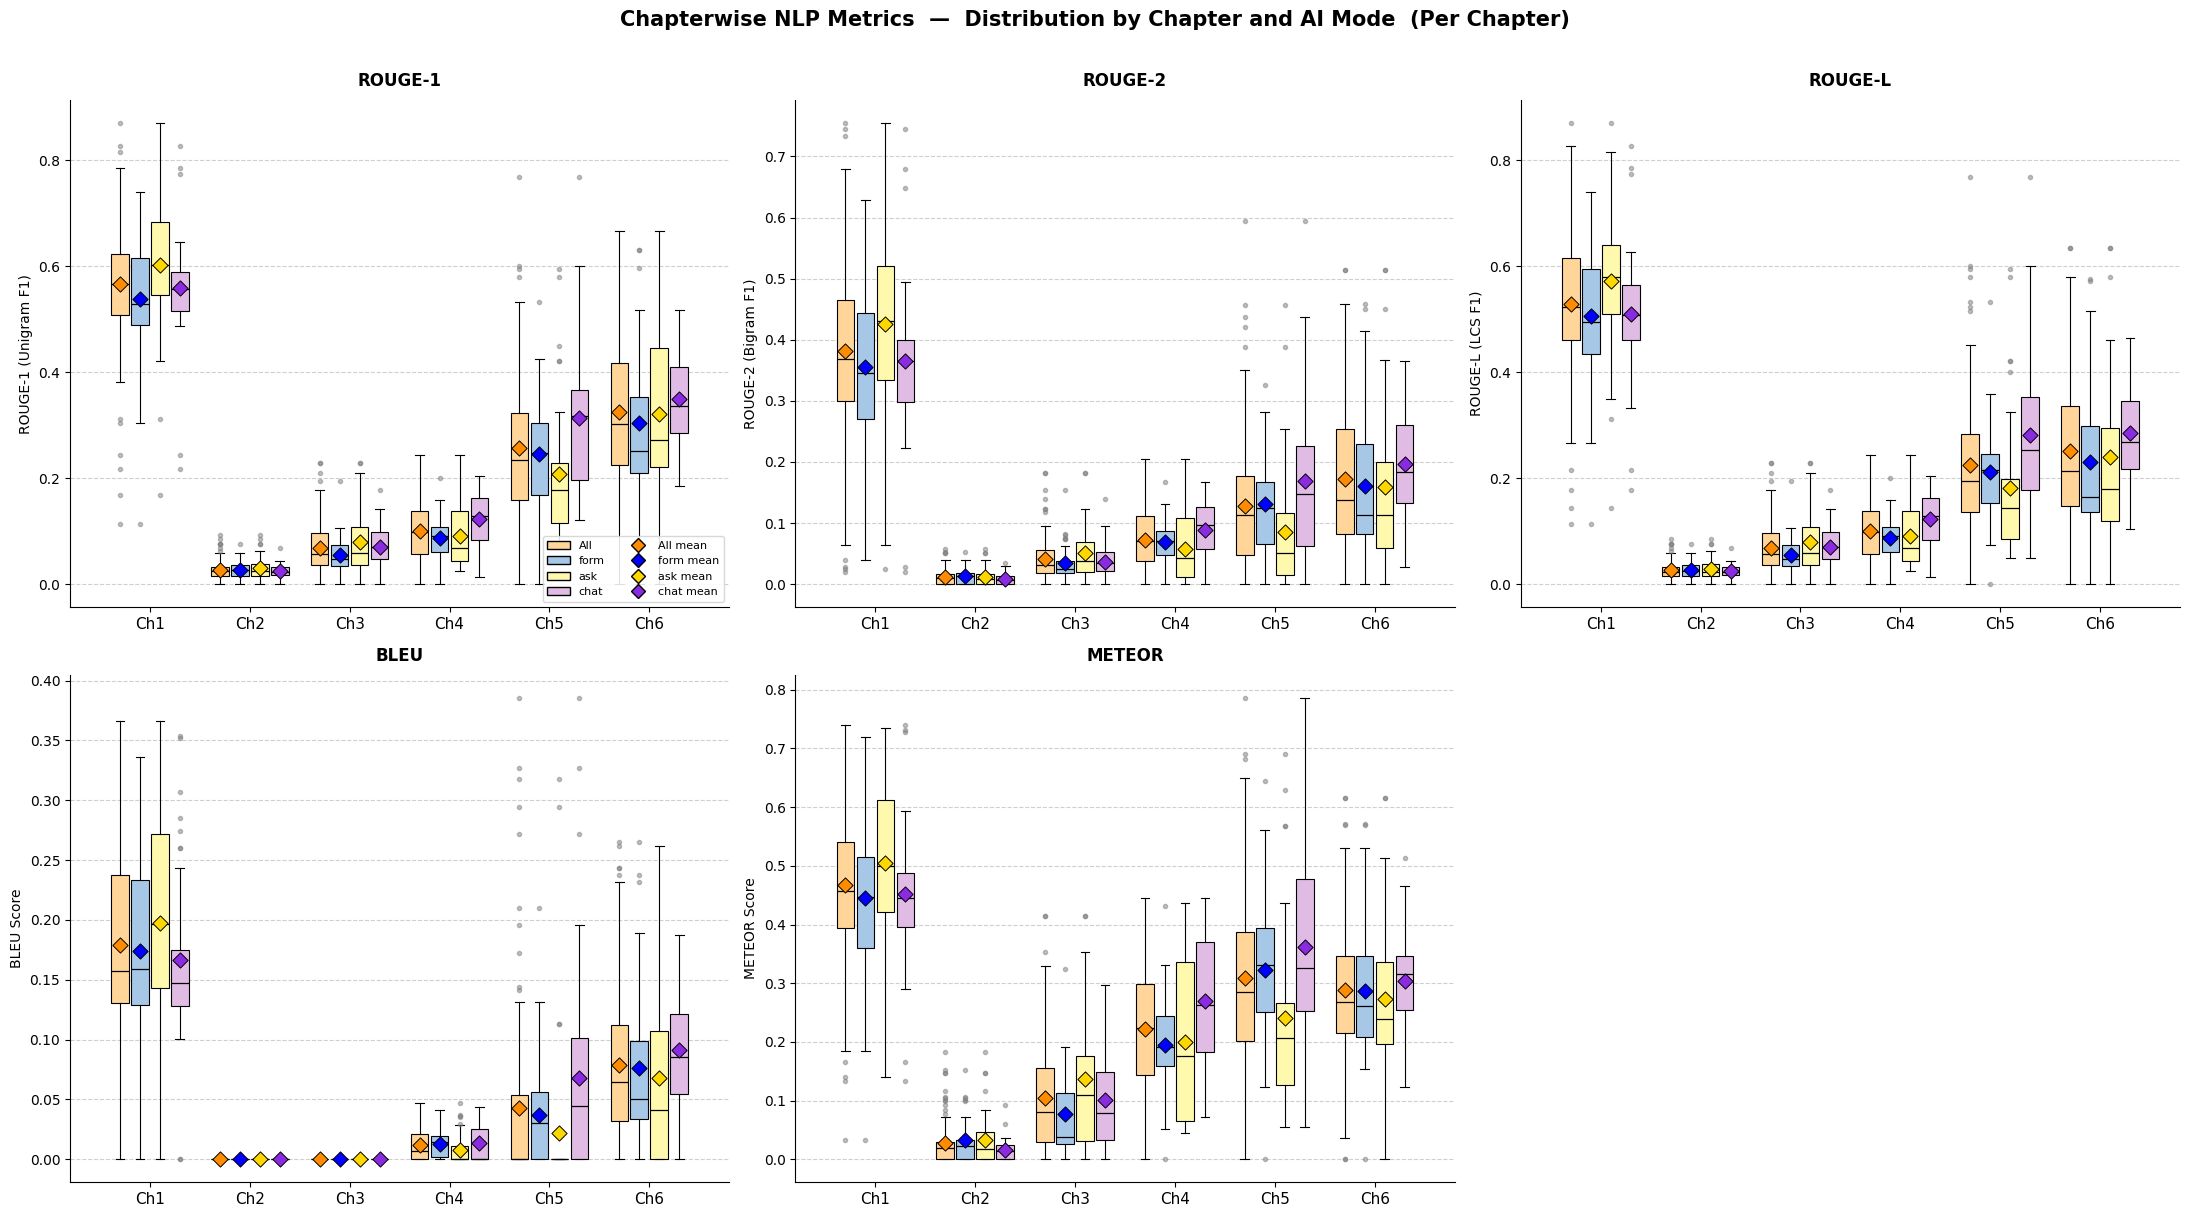

Saved output/chapter_nlp_metrics_boxplot.png


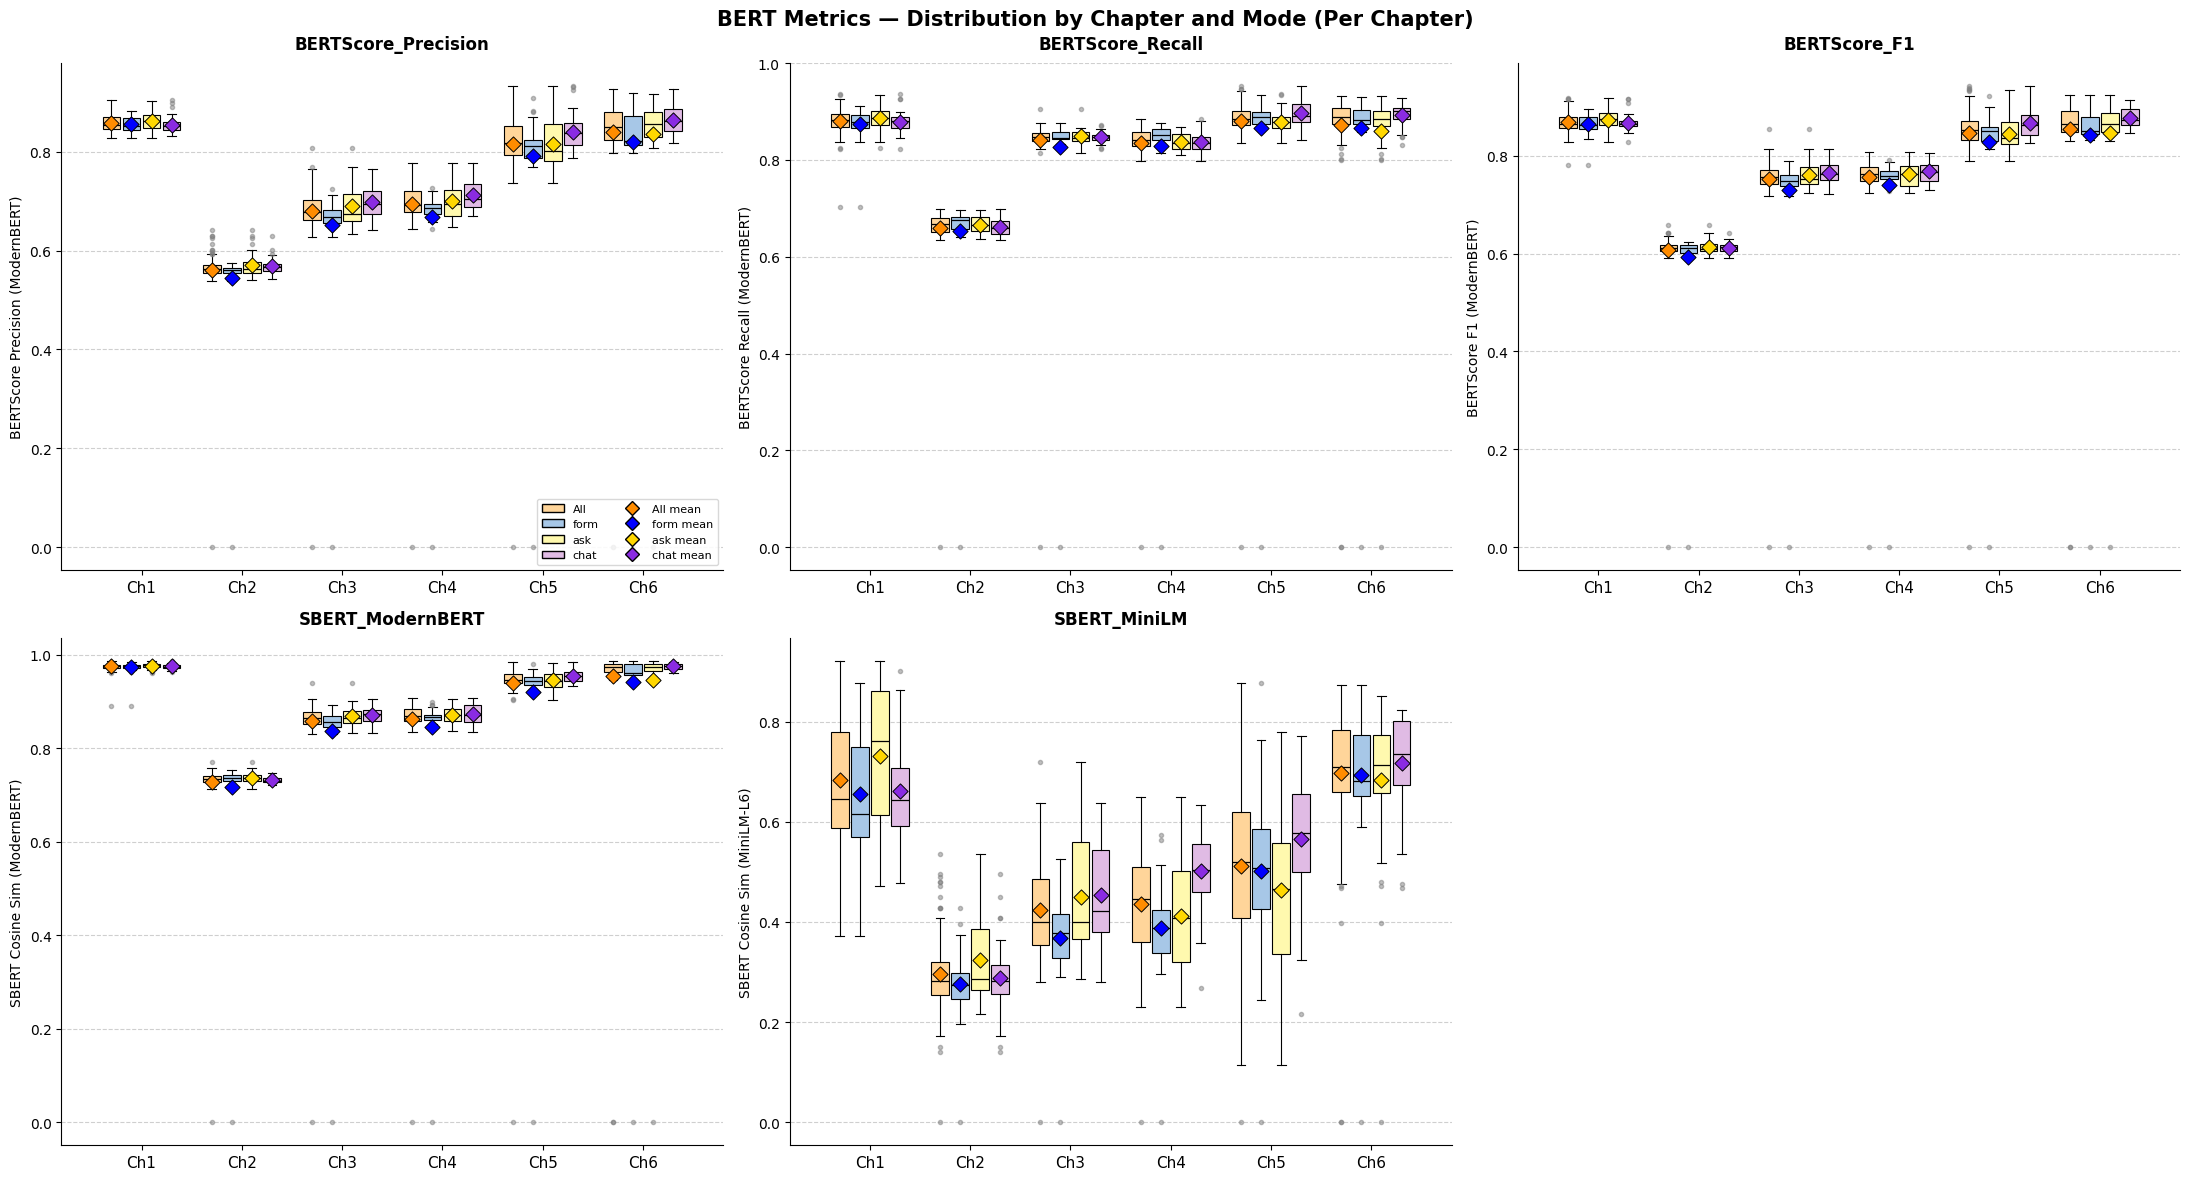

Saved output/chapter_bert_metrics_boxplot.png


In [127]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Palette (same as per-document plots) ───────────────────────────────────────────
GROUPS_CH      = ["All",     "form",    "ask",     "chat"]
BOX_COLORS_CH  = ["#FFD59A", "#A7C7E7", "#FFF9AE", "#E0BBE4"]
MEAN_COLORS_CH = ["#FF8C00", "#0000FF", "#FFD700", "#8A2BE2"]

# Short chapter labels for x-axis
X_LABELS = [f"Ch{i+1}" for i in range(len(CANONICAL_CHAPTERS))]


def _get_chapter_data(metric: str, mode: str, chapter: str) -> np.ndarray:
    if mode == "All":
        mask = df_chapters["chapter"] == chapter
    else:
        mask = (df_chapters["ai_mode"] == mode) & (df_chapters["chapter"] == chapter)
    return df_chapters.loc[mask, metric].dropna().values


def draw_chapter_boxplot(ax, metric: str, ylabel: str, ylim=None, add_legend: bool = False):
    """Draw one axes: x = chapters (Ch1-Ch6), groups = All + modes."""
    n_chapters = len(CANONICAL_CHAPTERS)
    n_groups   = len(GROUPS_CH)
    width      = 0.20
    offsets    = np.linspace(-(n_groups - 1) * width / 2,
                             (n_groups - 1) * width / 2, n_groups)

    all_vals_for_ylim = []

    for g_idx, (mode, box_col, mean_col) in enumerate(zip(GROUPS_CH, BOX_COLORS_CH, MEAN_COLORS_CH)):
        positions = [i + offsets[g_idx] for i in range(n_chapters)]
        data = [_get_chapter_data(metric, mode, ch) for ch in CANONICAL_CHAPTERS]

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=width * 0.88,
            patch_artist=True,
            showfliers=True,
            medianprops=dict(color="black", linewidth=0.9),
            whiskerprops=dict(color="black", linewidth=0.8),
            capprops=dict(color="black", linewidth=0.8),
            boxprops=dict(linewidth=0.8),
            flierprops=dict(marker="o", markerfacecolor="grey",
                            markeredgecolor="grey", markersize=3, alpha=0.5),
        )
        for patch in bp["boxes"]:
            patch.set_facecolor(box_col)
            patch.set_edgecolor("black")

        for i, (d, pos) in enumerate(zip(data, positions)):
            if len(d) > 0:
                ax.scatter(pos, np.mean(d), marker="D", s=60,
                           color=mean_col, edgecolors="black", linewidths=0.7, zorder=6)
                all_vals_for_ylim.append(d)

    ax.set_xticks(range(n_chapters))
    ax.set_xticklabels(X_LABELS, fontsize=11)

    # Dynamic y-axis limits based on actual data range
    if all_vals_for_ylim:
        all_vals = np.concatenate(all_vals_for_ylim)
        data_min, data_max = all_vals.min(), all_vals.max()
        data_range = data_max - data_min
        padding = max(data_range * 0.05, 0.01)
        ax.set_ylim(data_min - padding, data_max + padding)

    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(metric, fontsize=12, fontweight="bold", pad=10)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    if add_legend:
        box_patches = [
            mpatches.Patch(facecolor=bc, edgecolor="black", label=g)
            for g, bc in zip(GROUPS_CH, BOX_COLORS_CH)
        ]
        mean_handles = [
            plt.Line2D([0], [0], marker="D", color="w",
                       markerfacecolor=mc, markeredgecolor="black",
                       markersize=7, label=f"{g} mean")
            for g, mc in zip(GROUPS_CH, MEAN_COLORS_CH)
        ]
        ax.legend(handles=box_patches + mean_handles,
                  loc="lower right", fontsize=8, ncol=2,
                  framealpha=0.88, edgecolor="lightgrey")


# ── Figure 1: NLP metrics (BLEU · ROUGE-1/2/L · METEOR) ──────────────
CHAPTER_NLP_META = [
    ("ROUGE-1",  "ROUGE-1 (Unigram F1)",   (0.0, 1.0)),
    ("ROUGE-2",  "ROUGE-2 (Bigram F1)",    (0.0, 1.0)),
    ("ROUGE-L",  "ROUGE-L (LCS F1)",       (0.0, 1.0)),
    ("BLEU",     "BLEU Score",             None),
    ("METEOR",   "METEOR Score",           (0.0, 1.0)),
]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()
for i, (metric, ylabel, ylim) in enumerate(CHAPTER_NLP_META):
    draw_chapter_boxplot(axes[i], metric, ylabel, ylim, add_legend=(i == 0))
fig.delaxes(axes[5])
plt.suptitle(
    "Chapterwise NLP Metrics  —  Distribution by Chapter and AI Mode  (Per Chapter)",
    fontsize=15, fontweight="bold", y=1.01,
)
plt.tight_layout()
fname_ch_nlp = f"{OUT}/chapter_nlp_metrics_boxplot.png"
plt.savefig(fname_ch_nlp, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {fname_ch_nlp}")


# ── Figure 2: BERT Metrics (BERTScore P/R/F1 · SBERT ModernBERT · MiniLM) ─────
# Layout: 2x3
#   Row 0: BERTScore Precision | BERTScore Recall | BERTScore F1
#   Row 1: SBERT ModernBERT    | SBERT MiniLM     | (hidden)
CHAPTER_BERT_META = [
    ("BERTScore_Precision", "BERTScore Precision (ModernBERT)", (0.80, 1.00)),
    ("BERTScore_Recall",    "BERTScore Recall (ModernBERT)",    (0.80, 1.00)),
    ("BERTScore_F1",        "BERTScore F1 (ModernBERT)",        (0.80, 1.00)),
    ("SBERT_ModernBERT",    "SBERT Cosine Sim (ModernBERT)",    (0.70, 1.00)),
    ("SBERT_MiniLM",        "SBERT Cosine Sim (MiniLM-L6)",    (0.70, 1.00)),
]

# Check SBERT variance — note if near-zero
for metric, _, _ in CHAPTER_BERT_META[3:]:
    var = df_chapters[metric].var()
    if var < 1e-5:
        print(f"Note: {metric} has near-zero variance ({var:.2e}) — boxplot will appear flat.")

fig2, axes2 = plt.subplots(2, 3, figsize=(22, 12))
axes2 = axes2.flatten()
for i, (metric, ylabel, ylim) in enumerate(CHAPTER_BERT_META):
    draw_chapter_boxplot(axes2[i], metric, ylabel, ylim, add_legend=(i == 0))
axes2[5].set_visible(False)  # hide unused bottom-right cell
plt.suptitle(
    "BERT Metrics — Distribution by Chapter and Mode (Per Chapter)",
    fontsize=15, fontweight="bold",
)
plt.tight_layout()
fname_ch_bert = f"{OUT}/chapter_bert_metrics_boxplot.png"
plt.savefig(fname_ch_bert, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {fname_ch_bert}")